### Annual and monthly climatologies of key variables 
### Results: Section 1a

In [40]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings('ignore')

In [41]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
dataf = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_lai/"
datat = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_tropomi/"
dataclass = "/Volumes/New_5TB/ESA_F4R/landcover_classification/"

datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"congo_basin_evergreen.shp")

datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"geoBoundaries-COD-ADM0.shp")

In [42]:
fapar = xr.open_mfdataset(dataf+'fapar_*_reg_regrid.nc')
precip = xr.open_mfdataset(datac+'chirps_10day_reg_regrid.nc') 
lai = xr.open_mfdataset(datal+'lai_*_reg_regrid.nc') 
sif = xr.open_mfdataset(datac+'sif_10day_reg_regrid.nc') 
hdo = xr.open_mfdataset(datac+'hdo_10day_reg_regrid.nc') 
#hdo = hdo.where(hdo['deltaD']<60,np.nan)
tropess = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/F4R_data/tropess_gridded_caf_lowmid.nc') 
tropess = tropess.interp(lat=np.arange(tropess.coords["lat"].min().values,tropess.coords["lat"].max().values,0.25), lon=np.arange(tropess.coords["lon"].min().values,tropess.coords["lon"].max().values,0.25), method="linear")
    

In [43]:
vclass = xr.open_dataset(datac+'C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.area-subset.30.40.-30.0.nc') 

print(vclass)

vclass = vclass['lccs_class'].sel(lat=slice(12,-15),lon=slice(8,31),drop=True)
vclass = vclass.astype('int').load()
#vclass=vclass.where((vclass>=50) & (vclass=<150),drop=True)
#vclass=vclass.where(vclass.isin([10,30,40,50,60,70,80,90,110,120,130,150,200]),drop=True)
vclass_plot=vclass[-1,:,:]


<xarray.Dataset> Size: 4GB
Dimensions:              (time: 1, lat: 21600, lon: 14400, bounds: 2)
Coordinates:
  * time                 (time) datetime64[ns] 8B 2022-01-01
  * lat                  (lat) float64 173kB 30.0 30.0 29.99 ... -30.0 -30.0
  * lon                  (lon) float64 115kB 0.001389 0.004167 ... 40.0 40.0
Dimensions without coordinates: bounds
Data variables:
    lccs_class           (time, lat, lon) uint8 311MB ...
    processed_flag       (time, lat, lon) float32 1GB ...
    current_pixel_state  (time, lat, lon) float32 1GB ...
    observation_count    (time, lat, lon) uint16 622MB ...
    change_count         (time, lat, lon) uint8 311MB ...
    crs                  int32 4B ...
    lat_bounds           (lat, bounds) float64 346kB ...
    lon_bounds           (lon, bounds) float64 230kB ...
    time_bounds          (time, bounds) datetime64[ns] 16B ...
Attributes: (12/38)
    title:                      Land Cover Map of 2022
    summary:                    This da

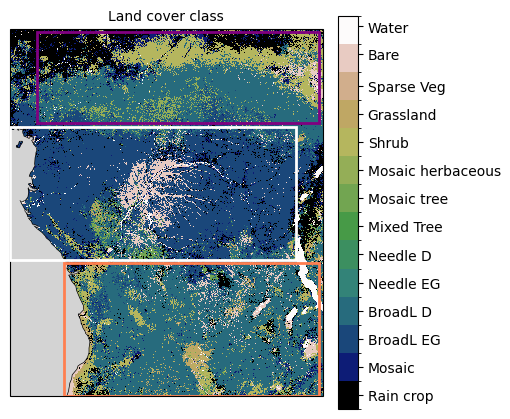

<Figure size 640x480 with 0 Axes>

In [44]:
fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},
                            layout="constrained",
                            figsize=(5,5))

#cmap=plt.cm.tab20b
cmap=plt.cm.gist_earth
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=vclass_plot.plot.pcolormesh(cmap=cmap,
                    levels=[0, 25, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 155, 202, 215],
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"vertical","shrink":0.8,
                                 'ticks': [12.5, 35, 50, 60, 70, 80, 90, 100, 110, 120, 130, 145, 185, 210]},
                    transform = ccrs.PlateCarree())
cst.colorbar.ax.set_yticklabels(['Rain crop','Mosaic','BroadL EG','BroadL D',
                                 'Needle EG','Needle D','Mixed Tree','Mosaic tree','Mosaic herbaceous',
                                 'Shrub','Grassland','Sparse Veg','Bare','Water'])#, rotation=45)
axs.add_patch(plt.Rectangle((10, 5.1), 20.7, 6.7, ls="-", lw=2, ec="purple", fc="none",zorder=3))
axs.add_patch(plt.Rectangle((8, -5), 21, 9.8, ls="-", lw=2, ec="white", fc="none",zorder=3))
axs.add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=2, ec="coral", fc="none",zorder=3))
#shp_cod.plot(ax=axs, edgecolor='orange',facecolor='none',lw=2,zorder=2,linestyle='-')
axs.set_title('Land cover class',fontsize=10)
axs.coastlines()
axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

plt.savefig(datap+'vclass.png')
plt.show()
plt.clf()

In [45]:
#fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
#
#vclass_broad_evergreen.plot.scatter(x='lon',y='lat',c='green',label='broadleaf evergreen >15%',transform = ccrs.PlateCarree())
#axs.set_title('Land cover class',fontsize=10)
#axs.coastlines()
#axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
#axs.legend() 
#
#plt.suptitle("Annual Average", fontsize=10)
#plt.savefig(datap+'annual_avg.png')
#plt.show()
#plt.clf()

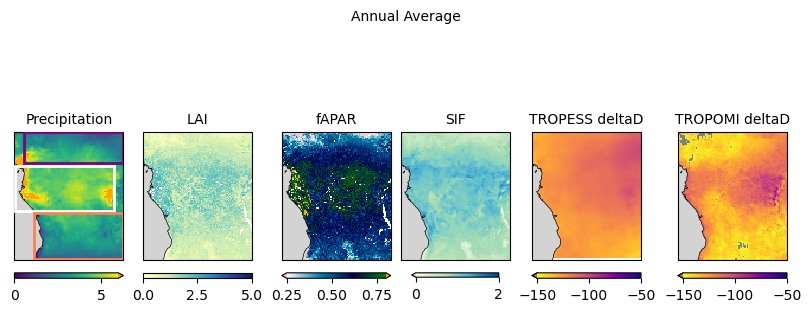

<Figure size 640x480 with 0 Axes>

In [46]:
ncols=6
nrows=1
h = nrows
w = ncols

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(8,3))
axs=axs.flatten()

cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=precip['precip'].mean('time').plot.pcolormesh(ax=axs[0],
                    vmin=0, vmax=6,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=2, ec="purple", fc="none",zorder=3))
axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=2, ec="white", fc="none",zorder=3))
axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=2, ec="coral", fc="none",zorder=3))
axs[0].set_title('Precipitation',fontsize=10)
axs[0].set_ylabel('EQ')
axs[0].coastlines()
axs[0].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.YlGnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=lai['LAI'].mean('time').plot.pcolormesh(ax=axs[1],
                    vmin=0, vmax=5,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[1].set_title('LAI',fontsize=10)
axs[1].coastlines()
axs[1].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.ocean_r
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=fapar['fAPAR'].mean('time').plot.pcolormesh(ax=axs[2],
                    vmin=0.25, vmax=0.8,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[2].set_title('fAPAR',fontsize=10)
axs[2].coastlines()
axs[2].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.GnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=sif['SIF'].mean('time').plot.pcolormesh(ax=axs[3],
                    cmap=cmap,
                    vmin=0, vmax=2,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal","shrink":0.8},
                    transform = ccrs.PlateCarree())
axs[3].set_title('SIF',fontsize=10)
axs[3].coastlines()
axs[3].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')
cst=tropess['deltaD'].mean('time').plot.pcolormesh(ax=axs[4],
                    vmin=-150, vmax=-50.0,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[4].set_title('TROPESS deltaD',fontsize=10)
axs[4].coastlines()
axs[4].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')
cst=hdo['deltaD'].mean('time').plot.pcolormesh(ax=axs[5],
                    vmin=-150, vmax=-50.0,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[5].set_title('TROPOMI deltaD',fontsize=10)
axs[5].coastlines()
axs[5].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

#cmap=plt.cm.tab20b
#cmap.set_extremes(over='orange')
#cmap.set_extremes(under='pink')
#cst=vclass_plot.plot.pcolormesh(ax=axs[5],
#                    cmap=cmap,
#                    levels=[45,55,65,75,85,95,105,125,135],
#                    rasterized=True,
#                    cbar_kwargs={"label": "","orientation":"horizontal","shrink":0.8,
#                                 'ticks': [50, 60, 70, 80, 90,110,120, 130]},
#                    transform = ccrs.PlateCarree())
#cst.colorbar.ax.set_xticklabels(['BroadL EG','BroadL D','Needle EG','Needle D','Mixed Tree','Mosaic','Shrub','Grassland'], rotation=45)
#axs[5].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=2, ec="purple", fc="none",zorder=3))
#axs[5].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=2, ec="white", fc="none",zorder=3))
#axs[5].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=2, ec="coral", fc="none",zorder=3))
#axs[5].set_title('Land cover class',fontsize=10)
#axs[5].coastlines()
#axs[5].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

plt.suptitle("Annual Average", fontsize=10)
plt.savefig(datap+'annual_avg.png')
plt.show()
plt.clf()

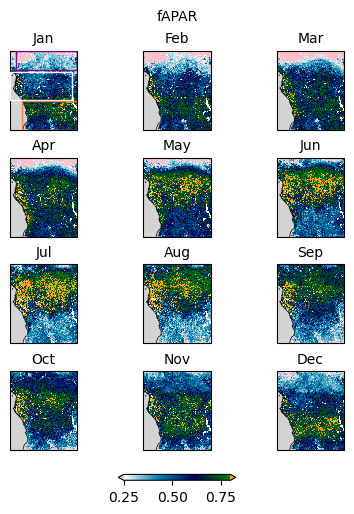

<Figure size 640x480 with 0 Axes>

In [47]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = fapar['fAPAR'].groupby('time.month').mean('time')

cmap=plt.cm.ocean_r
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0.25, vmax=0.8,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("fAPAR", fontsize=10)
plt.savefig(datap+'mon_clim_fapar.png')
plt.show()
plt.clf()

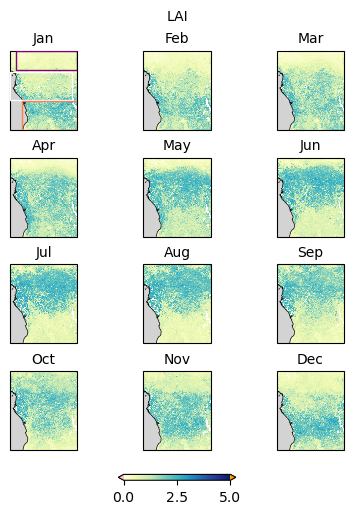

<Figure size 640x480 with 0 Axes>

In [48]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = lai['LAI'].groupby('time.month').mean('time')

cmap=plt.cm.YlGnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0.0, vmax=5.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("LAI", fontsize=10)
plt.savefig(datap+'mon_clim_lai.png')
plt.show()
plt.clf()

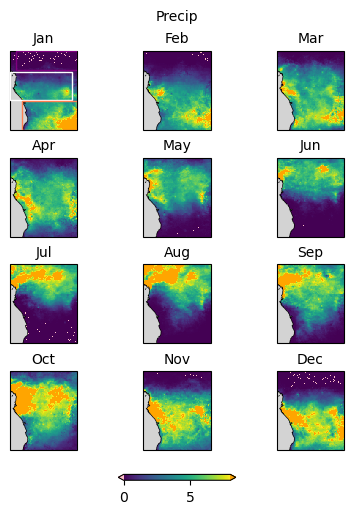

<Figure size 640x480 with 0 Axes>

In [49]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = precip['precip'].groupby('time.month').mean('time')

cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0.0, vmax=8.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("Precip", fontsize=10)
plt.savefig(datap+'mon_clim_precip.png')
plt.show()
plt.clf()

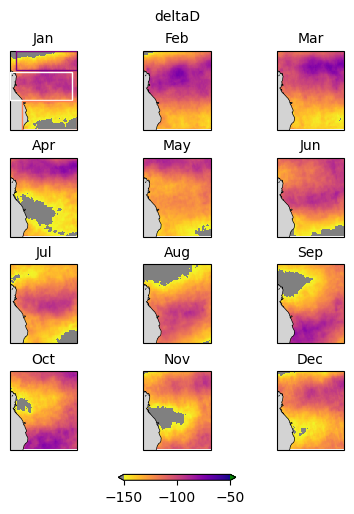

<Figure size 640x480 with 0 Axes>

In [50]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = tropess['deltaD'].groupby('time.month').mean('time')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=-150, vmax=-50.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("deltaD", fontsize=10)
plt.savefig(datap+'mon_clim_tropess_deltaD.png')
plt.show()
plt.clf()

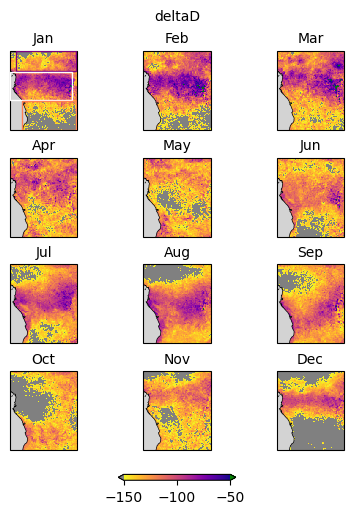

<Figure size 640x480 with 0 Axes>

In [51]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = hdo['deltaD'].groupby('time.month').mean('time')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=-150, vmax=-50.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("deltaD", fontsize=10)
plt.savefig(datap+'mon_clim_hdo_deltaD.png')
plt.show()
plt.clf()

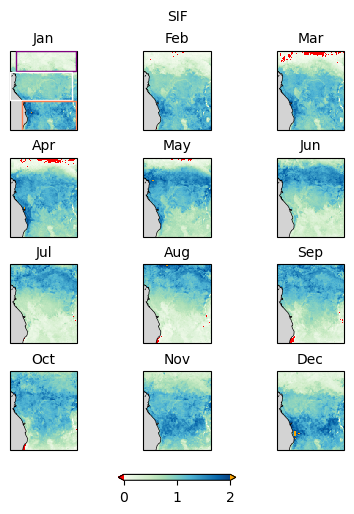

<Figure size 640x480 with 0 Axes>

In [52]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = sif['SIF'].groupby('time.month').mean('time')

cmap=plt.cm.GnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='red')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=2,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("SIF", fontsize=10)
plt.savefig(datap+'mon_clim_deltaD.png')
plt.show()
plt.clf()